In [ ]:
# use linear regression to fit relation from image property principal components to functional signal
# visualization of result
#1 model performance, including correlation and statistical significance
#2 model weight, cortex pattern of each property pcs in surface mesh

### image distribution in prop pcs space

In [3]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.io as scio
from os.path import join as pjoin


basedir = r'/n02dat01/users/qdzhao/THINGS'
outdir_ = pjoin(basedir, r'property_analysis/derivatives/2_pro_relation')
ind = scio.loadmat(pjoin(outdir_, f'index_1854to720.mat'))
ind_1854to720 = ind['index_1854to720'][0].squeeze().tolist()
# print(len(ind_1854to720))

obj_pro_pcs_ = scio.loadmat(pjoin(basedir, r'property_analysis/derivatives/2_pro_relation', f'obj_pro_pcs.mat'))
obj_pro_pcs__ = obj_pro_pcs_['obj_pro_pcs']
obj_pro_pcs = obj_pro_pcs__[ind_1854to720,:]
print(obj_pro_pcs.shape) # (720,5)

# plt.figure(figsize=(6, 6))
# plt.scatter(obj_pro_pcs[:,0], obj_pro_pcs[:,1])
# plt.axhline(0, c='r') # 画出 x=0 这条水平线
# plt.axvline(0, c='r') # 画出 x=0 这条垂直线
# plt.xlabel('pc1')
# plt.ylabel('pc2')
# plt.show()

# plt.scatter(obj_pro_pcs[:,0], obj_pro_pcs[:,2])
# plt.axhline(0, c='r')
# plt.axvline(0, c='r')
# plt.xlabel('pc1')
# plt.ylabel('pc3')
# plt.show()

# plt.scatter(obj_pro_pcs[:,1], obj_pro_pcs[:,2])
# plt.axhline(0, c='r')
# plt.axvline(0, c='r')
# plt.xlabel('pc2')
# plt.ylabel('pc3')
# plt.show()

(720, 5)


ind0 selective images


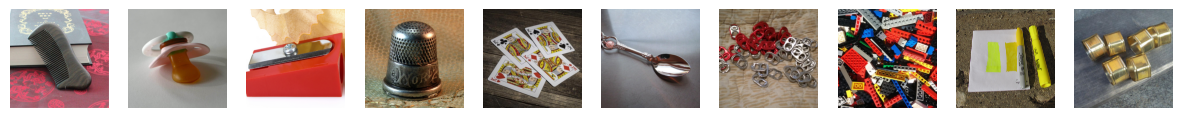

ind1 selective images


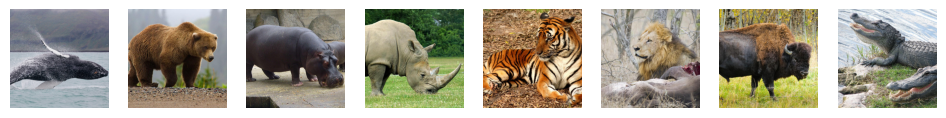

ind2 selective images


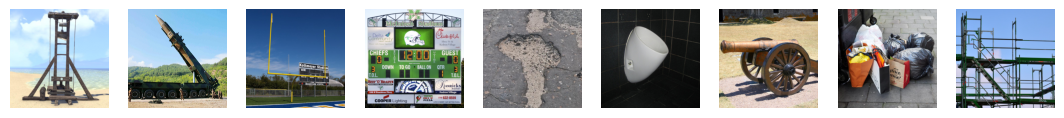

ind3 selective images


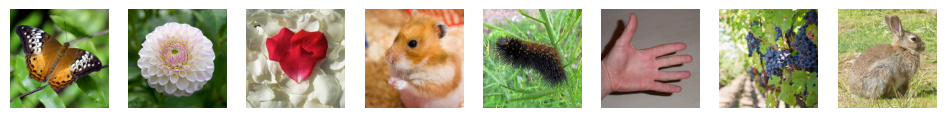

ind4 selective images


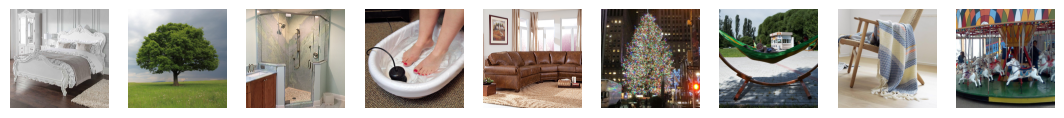

ind5 selective images


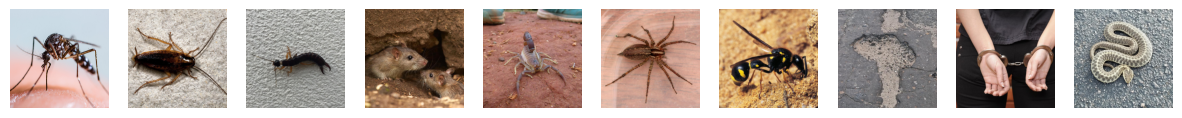

In [72]:
# give imgs of each prop pc
import pandas as pd
import matplotlib.image as im
import matplotlib.pyplot as plt

# load category names
cat_tsv = r'D:\visual_project\THINGS_project\THINGS_stimuli\THINGS\things_concepts.tsv'
cat_df = pd.read_csv(cat_tsv, sep='\t').drop(columns='Definition (from WordNet, Google, or Wikipedia)')
cat_df_ = np.array(cat_df.loc[ind_1854to720]['Word'].squeeze().tolist())

wsort = []
for i in range(3):
    ind = np.argsort(obj_pro_pcs[:,i]) # from small to large
    wn_sort = cat_df_[ind]
    wsort.append(wn_sort)
    ind = np.argsort(-obj_pro_pcs[:,i]) # from large to small
    wn_sort = cat_df_[ind]
    wsort.append(wn_sort)

# comp prefer images show
img_set_dir =pjoin(r'D:\visual_project\THINGS_project\THINGS_stimuli\THINGS\Images')
img_partitions = os.listdir(img_set_dir)
# find images
image_list = []
for c in range(len(wsort)): # 6
    img_list = [] # top 10 imgs of each comp
    for cc in wsort[c][:10]:
        for p in img_partitions:
            part_dir = os.path.join(img_set_dir, p) # imageset A-Z
            img_partitions_ = os.listdir(part_dir)
            for pp in img_partitions_:
                part_dir_ = os.path.join(part_dir, pp) # image category aardvark to zucchini
                if pp[-1] in ['1', '2']:# some concepts are coded 'bracelet2' or 'bow1', we just count them as individuals
                    pp = pp[:-1]
                pp = pp.replace('_', ' ') # standardize the name of images
                if pp==cc:
                    for root, dirs, files in os.walk(part_dir_):
                        for file in files:
                            if file.endswith("02s.jpg") or file.endswith("02s.JPEG"):
                                img_list.append(pjoin(root,file))
    image_list.append(img_list)
# show images 
for c in range(len(wsort)):
    plt.figure(figsize=(15,15))
    print('ind%d selective images' %c)
    i = 1
    for item in image_list[c]:
        img = im.imread(item)
        plt.subplot(6,10,(c*10+i))
        plt.imshow(img)
        plt.axis('off')
        i += 1
    plt.show()
#ref https://blog.csdn.net/qq_46126258/article/details/107705262

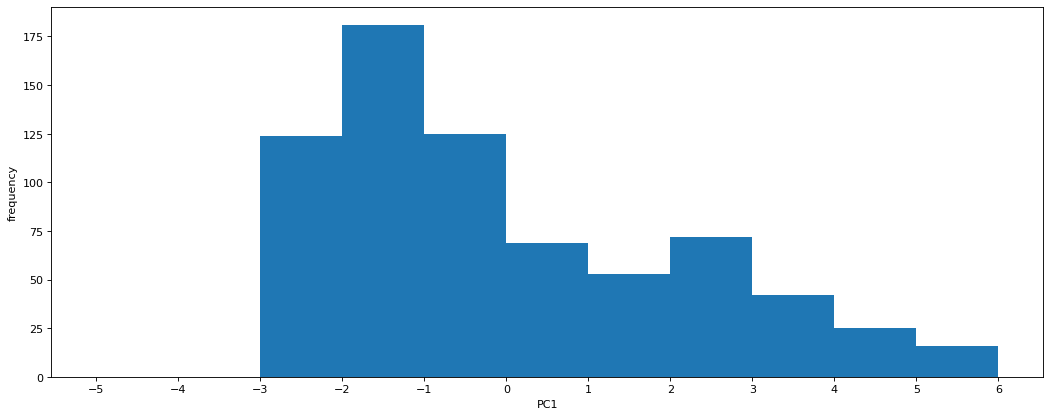

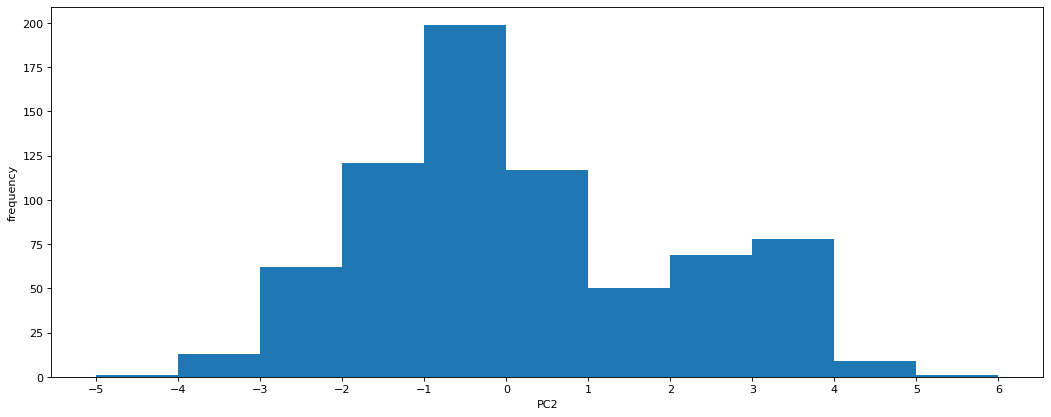

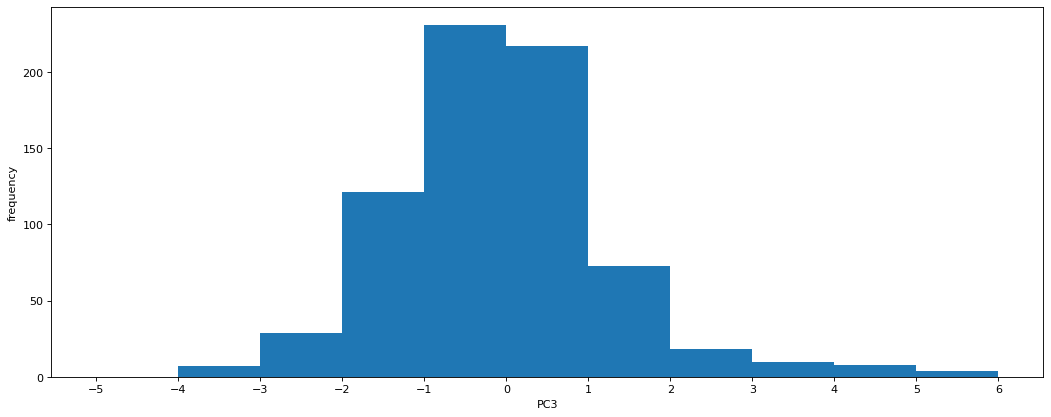

In [59]:
#属性pc分布直方图

d = 1
#组数
# np.max(obj_pro)=4.5, np.min(obj_pro)=-4
pro_nm = ['PC1','PC2','PC3']
num_bin = np.arange(-5,7,d)
#print(max(a)-min(a),max(a),min(a))
for i in range(3):
    plt.figure(figsize=(16,6),dpi=80)

    plt.hist(obj_pro_pcs[:,i], num_bin)
    plt.xticks(num_bin)
    plt.xlabel(pro_nm[i])
    plt.ylabel('frequency')
#     plt.title('property histogram',size=15)
#     plt.grid(alpha=0.4)
    plt.show()


100%|██████████| 720/720 [00:01<00:00, 366.74it/s]


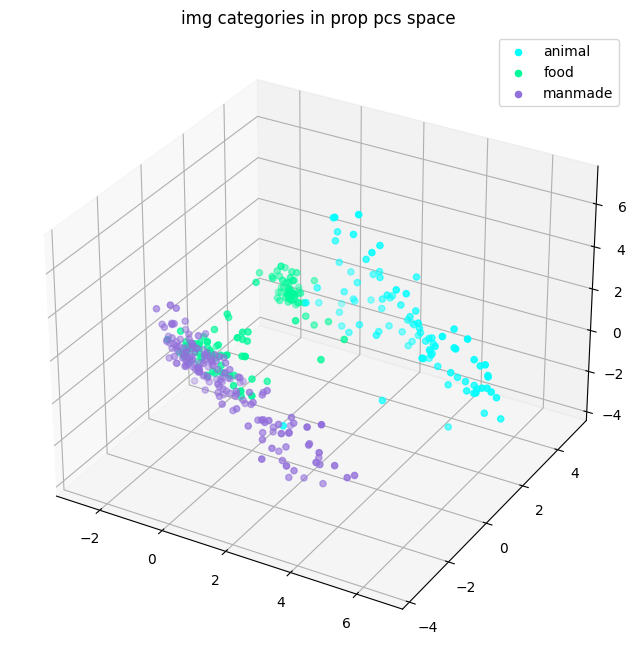

In [59]:
from os.path import join as pjoin
from sklearn.cluster import KMeans
import numpy as np
import glob
import os
import sys
import pandas as pd
import scipy.io as scio
# from sklearn.manifold import MDS
# from sklearn.decomposition import PCA
from tqdm import *
import matplotlib.pyplot as plt


sys.path.append(pjoin(os.pardir, os.pardir, 'external_libraries'))

sub = '01'
basedir = r'/n02dat01/users/qdzhao/THINGS'
# read functional data
betas_csv_dir = pjoin(basedir, r'THINGS_fMRI/betas_csv')
# data_file = pjoin(betas_csv_dir, f'sub-{sub}_ResponseData.h5')
# responses = pd.read_hdf(data_file)
stim_f = pjoin(betas_csv_dir, f'sub-{sub}_StimulusMetadata.csv')
stimdata = pd.read_csv(stim_f)
# average betas within concept
filenames = stimdata.loc[:]['stimulus']
concepts = np.array([
    fn[0:fn.rfind('_')]
    for fn in filenames
])
unique_concepts = np.unique(concepts) # 720

def run_Dred_on_data(
        basedir,
        unique_concepts,
        target_cats,
        target_colors,
        seed=2024,
):
    
    np.random.seed(seed)
    # if colors are passed as RBG tuples, normalize to 0-1
    for i, color in enumerate(target_colors):
        if type(color) == tuple:
            target_colors[i] = tuple([e/255 for e in color])
    # define file names
#     outdir = pjoin(basedir, r'animacy_analysis\derivatives\2_pro_relation\prop_pcs')
# #     out_npy = pjoin(outdir, f'{target_cats[0][0]}_{target_cats[1][0]}_{target_cats[2][0]}.npy')
#     out_png = pjoin(outdir, f'prop_pc23.png')
#     out_png = out_npy.replace('.npy', '.png')
#     if not os.path.exists(outdir):
#         os.makedirs(outdir)

    # load category names
    cat_tsv = pjoin(basedir, r'THINGS_stimuli/THINGS', f'things_concepts.tsv')
    cat_df = pd.read_csv(cat_tsv, sep='\t').drop(columns='Definition (from WordNet, Google, or Wikipedia)')
    stim_ind = []
    for c in tqdm(unique_concepts):
        if c[-1] in ['1', '2']:# some concepts are coded 'bracelet2' or 'bow1', we just count them as individuals
            c = c[:-1]
        inds = np.where(cat_df['Word'] == c.replace('_', ' '))
        stim_ind.append(inds[0][0])
    cat_df = cat_df.loc[stim_ind] # 1854->720
    
    cats = []
    for con in unique_concepts:
        if con[-1] in ['1', '2']:  # some concepts are coded 'bracelet2' or 'bow1', we just count them as individuals
            con = con[:-1]
        row = cat_df.loc[cat_df['Word'] == con.replace('_', ' ')]
        #hits = [cat for cat in target_cats if row[cat].values[0] == 1]
        hits = []
        for i in range(len(target_cats)):
            for cat in target_cats[i][1]:
                if row['Bottom-up Category (Human Raters)'].values[0] == cat:
                    hits = [target_cats[i][0]]
#         hits = [cat for cat in target_cats if row['Bottom-up Category (Human Raters)'].values[0] == cat]
        result = hits[0] if len(hits) else 'others'  # only keep the first category found, or "Other"
        cats.append(result)
    cats = np.array(cats)
#     sort = np.argsort(cats)
#     cats = cats[sort]

#     Y = Y_[sort]    
#     # plot and save
#     colors_ = target_colors + ['lightgrey']
#     labels_ = [target_cats[0][0],target_cats[1][0],target_cats[2][0]] + ['all other']
#     fig = plt.figure(figsize=(6,6))
#     g = sns.scatterplot(
#         x=Y[:, 1], y=Y[:, 2], hue=cats, hue_order=labels_, palette=colors_,
#         s=40, alpha=.7, linewidth=0, legend=True)
#     plt.axhline(0, c='r') # 画出 x=0 这条水平线
#     plt.axvline(0, c='r') # 画出 x=0 这条垂直线
#     plt.xlabel('pc2')
#     plt.ylabel('pc3')
#     plt.show()
#     fig.savefig(out_png, dpi=300)
    return cats


cat1 = ['animal','animal, bird','animal, insect','bird','body part','insect','plant']
cat2 = ['dessert','dessert, drink','drink','food','food, dessert','food, fruit','food, plant','food, vegetable','fruit','vegetable','vegetable, fruit']
cat3 = ['clothing','clothing accessory','clothing, clothing accessory','container','electronic device','furniture','furniture, home decor','home decor','kitchen appliance','kitchen tool' 'kitchen tool, kitchen appliance','medical equipment','musical instrument','sports equipment','sports equipment, toy','tool','tool, kitchen tool','tool, office supply','tool, sports equipment','tool, weapon','toy','toy, weapon','vehicle','vehicle, toy','weapon','part of car']
# 
# col1, col2 ,col3 = 'rebeccapurple', 'mediumspringgreen', 'lightskyblue'
col1, col2 ,col3 = 'cyan','mediumspringgreen','mediumpurple'
# cat1, cat2, col1, col2 = 'vehicle', 'tool', 'lightskyblue', 'mediumvioletred'
# print(len(cat1)+len(cat2)+len(cat3)) = 42
cats = run_Dred_on_data(basedir, unique_concepts, target_cats=[['animal',cat1],['food',cat2],['manmade',cat3]], target_colors=[col1,col2,col3])
# (720 labels)

outdir_ = pjoin(basedir, r'property_analysis/derivatives/2_pro_relation')
ind = scio.loadmat(pjoin(outdir_, f'index_1854to720.mat'))
ind_1854to720 = ind['index_1854to720'][0].squeeze().tolist()
# property space
obj_pro_pcs_ = scio.loadmat(pjoin(outdir_, f'obj_pro_pcs.mat'))
obj_pro_pcs__ = obj_pro_pcs_['obj_pro_pcs']
obj_pro_pcs = obj_pro_pcs__[ind_1854to720,:3] #(720,3)

# fdir = pjoin(basedir, r'animacy_analysis\derivatives\3_pro_representation\linear model','sub-'+sub, 'prop_pcs')

cat1_idx = []
cat2_idx = []
cat3_idx = []
cat_others = []
# clu4 = []
# clu5 = []
for i in range(len(cats)):
    if cats[i]=='animal':
        cat1_idx.append(i)
    if cats[i]=='food':
        cat2_idx.append(i)
    if cats[i]=='manmade':
        cat3_idx.append(i)
    if cats[i]=='others':
        cat_others.append(obj_pro_pcs[i])
#     if yhat[i]==3:
#         clu4.append(pcwei_s[i])
#     if yhat[i]==4:
#         clu5.append(pcwei_s[i])
# print(len(cat1_)+len(cat2_)+len(cat3_)+len(cat_others))

cat1_ = obj_pro_pcs[cat1_idx]
cat2_ = obj_pro_pcs[cat2_idx]
cat3_ = obj_pro_pcs[cat3_idx]
cat_others = np.array(cat_others)
# clu4 = np.array(clu4)
# clu5 = np.array(clu5)

# sub-01 =[r,o,g,b], sub02=[r,b,o,g], sub03=[o,r,b,g]
# sub-01 =[r,g,b], sub02=[b,g,r], sub03=[b,r,g]
plt.figure(figsize=(10,8))
plt.rc('font',family='Arial', size=10)
ax = plt.axes(projection="3d")
ax.scatter(cat1_[:,0],cat1_[:,1],cat1_[:,2], color=col1, label='animal')
ax.scatter(cat2_[:,0],cat2_[:,1],cat2_[:,2], color=col2, label='food')
ax.scatter(cat3_[:,0],cat3_[:,1],cat3_[:,2], color=col3, label='manmade')
# ax.scatter(cat_others[:,0],cat_others[:,1],cat_others[:,2], color='lightgrey', label='others')
# ax.scatter3D(clu4[:,0],clu4[:,1],clu4[:,2], color="g")

# ax.set(xlabel='PC1',ylabel='PC2',zlabel='PC3')
plt.title("img categories in prop pcs space")
# ax.set(xticklabels=[],
#        yticklabels=[],
#        zticklabels=[])
# 显示图形
plt.legend(loc='upper right')
plt.show()


animal
ind0 selective images


<Figure size 1500x1500 with 0 Axes>

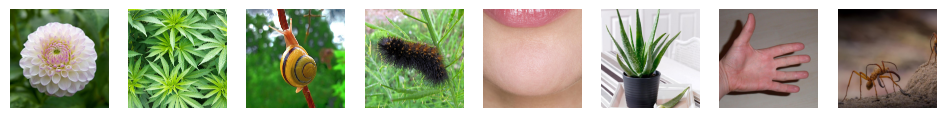

ind1 selective images


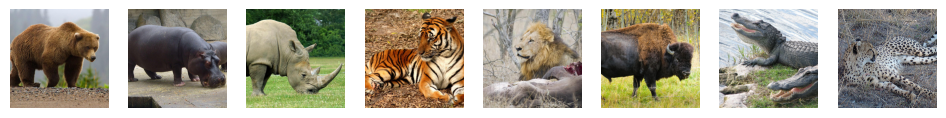

ind2 selective images


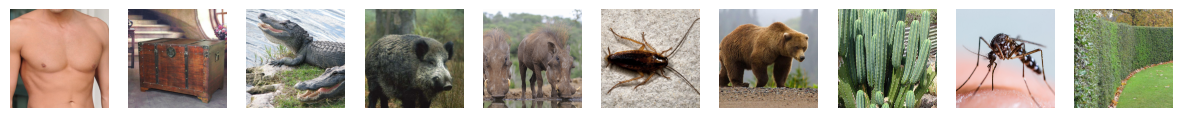

ind3 selective images


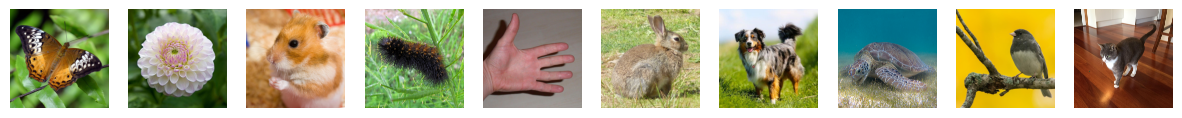

ind4 selective images


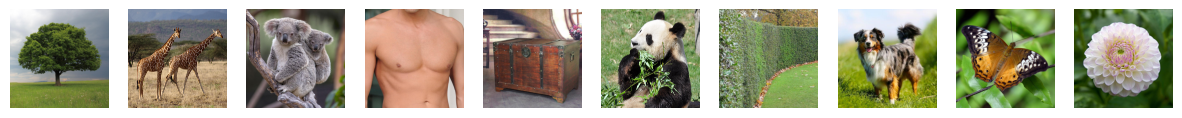

ind5 selective images


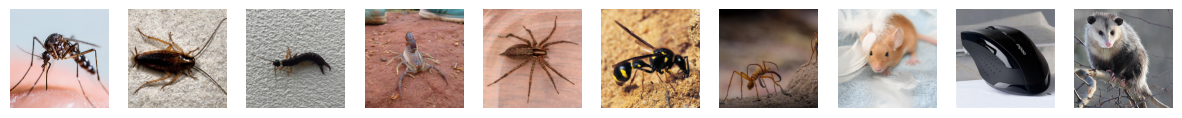

food
ind0 selective images


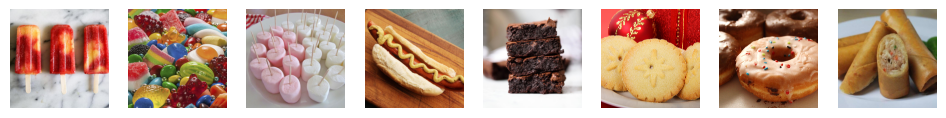

ind1 selective images


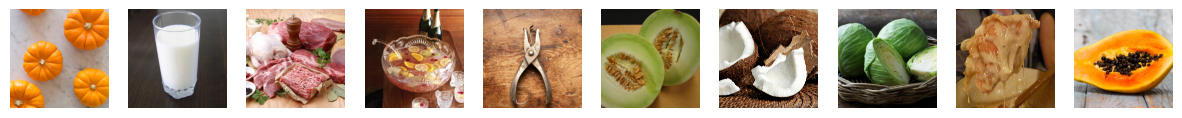

ind2 selective images


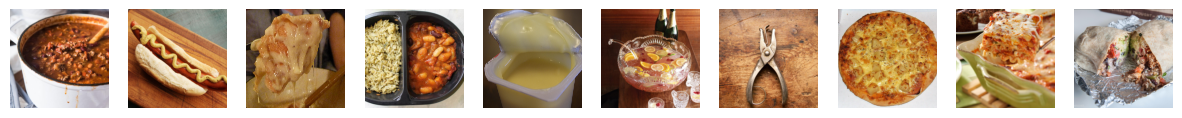

ind3 selective images


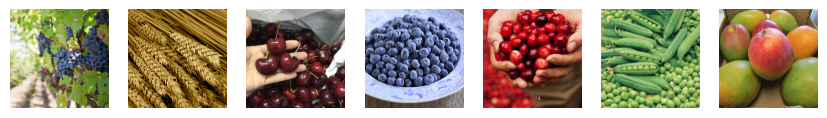

ind4 selective images


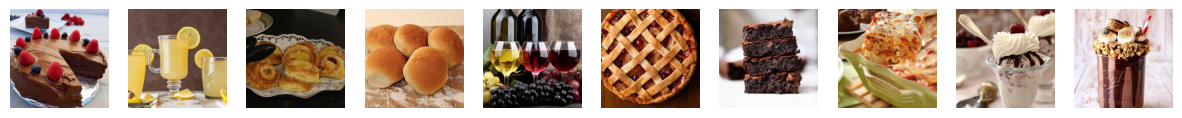

ind5 selective images


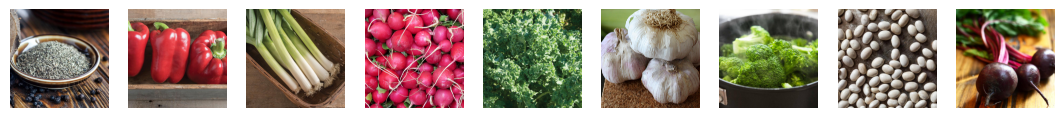

manmade
ind0 selective images


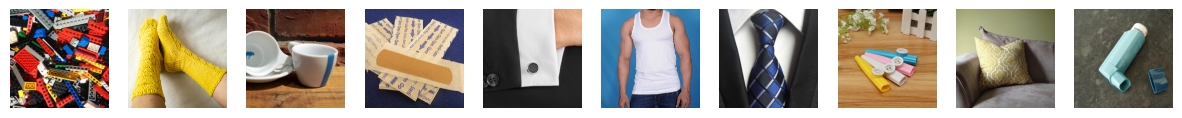

ind1 selective images


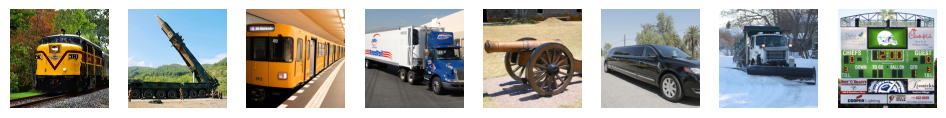

ind2 selective images


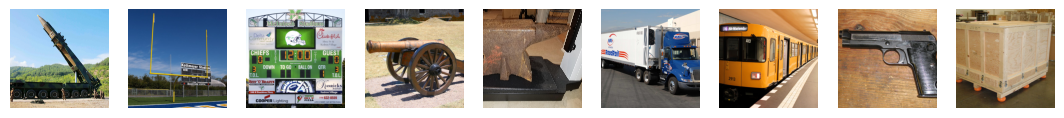

ind3 selective images


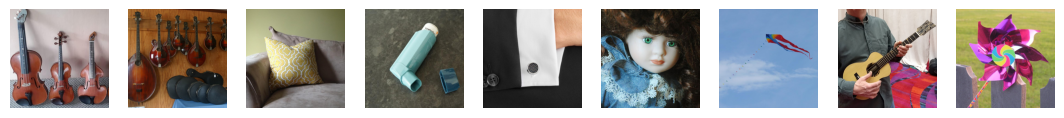

ind4 selective images


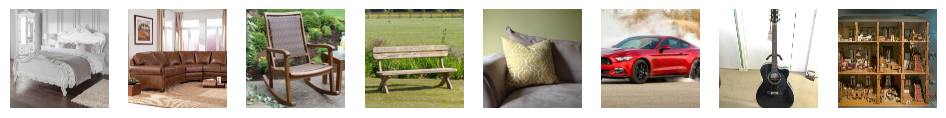

ind5 selective images


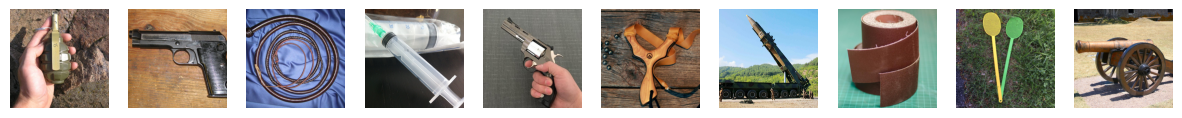

In [37]:
# give imgs of each prop pc evenly(均匀的)
import pandas as pd
import matplotlib.image as im
import matplotlib.pyplot as plt

# load category names
cat_tsv = pjoin(basedir, r'THINGS_stimuli/THINGS',f'things_concepts.tsv')
cat_df = pd.read_csv(cat_tsv, sep='\t').drop(columns='Definition (from WordNet, Google, or Wikipedia)')
cat_df_ = np.array(cat_df.loc[ind_1854to720]['Word'].squeeze().tolist())


# comp prefer images show
def img_show(wsort):
    img_set_dir =pjoin(r'/n02dat01/users/qdzhao/THINGS/THINGS_stimuli/THINGS/Images')
    img_partitions = os.listdir(img_set_dir)
    # find images
    image_list = []
    for c in range(len(wsort)): # 3
        img_list = [] # top 10 imgs of each comp
        for cc in wsort[c][:10]:
            for p in img_partitions:
                part_dir = os.path.join(img_set_dir, p) # imageset A-Z
                img_partitions_ = os.listdir(part_dir)
                for pp in img_partitions_:
                    part_dir_ = os.path.join(part_dir, pp) # image category aardvark to zucchini
                    if pp[-1] in ['1', '2']:# some concepts are coded 'bracelet2' or 'bow1', we just count them as individuals
                        pp = pp[:-1]
                    pp = pp.replace('_', ' ') # standardize the name of images
                    if pp==cc:
                        for root, dirs, files in os.walk(part_dir_):
                            for file in files:
                                if file.endswith("02s.jpg") or file.endswith("02s.JPEG"):
                                    img_list.append(pjoin(root,file))
        image_list.append(img_list)
    # show images
    for c in range(len(wsort)):
        plt.figure(figsize=(15,15))
        print('ind%d selective images' %c)
        i = 1
        for item in image_list[c]:
            img = im.imread(item)
            plt.subplot(6,10,(c*10+i))
            plt.imshow(img)
            plt.axis('off')
            i += 1
        plt.show()

cat1_ = obj_pro_pcs[cat1_idx]
cat2_ = obj_pro_pcs[cat2_idx]
cat3_ = obj_pro_pcs[cat3_idx]

print('animal')
wsort = [] 
for i in range(3):
    ind = np.argsort(cat1_[:,i]) # from samll to large
    wn_sort_ = np.array(cat1_idx)[ind].tolist()
    wn_sort = cat_df_[wn_sort_]
    wsort.append(wn_sort[:10])
    ind = np.argsort(-cat1_[:,i]) # from large to small
    wn_sort_ = np.array(cat1_idx)[ind].tolist()
    wn_sort = cat_df_[wn_sort_]
    wsort.append(wn_sort)
img_show(wsort)

print('food')
wsort = [] #(3,11)
for i in range(3):
    ind = np.argsort(cat2_[:,i]) # from samll to large
    wn_sort_ = np.array(cat2_idx)[ind].tolist()
    wn_sort = cat_df_[wn_sort_]
    wsort.append(wn_sort)
    ind = np.argsort(-cat2_[:,i]) # from large to small
    wn_sort_ = np.array(cat2_idx)[ind].tolist()
    wn_sort = cat_df_[wn_sort_]
    wsort.append(wn_sort)
img_show(wsort)

print('manmade')
wsort = [] #(3,11)
for i in range(3):
    ind = np.argsort(cat3_[:,i]) # from samll to large
    wn_sort_ = np.array(cat3_idx)[ind].tolist()
    wn_sort = cat_df_[wn_sort_]
    wsort.append(wn_sort)
    ind = np.argsort(-cat3_[:,i]) # from large to small
    wn_sort_ = np.array(cat3_idx)[ind].tolist()
    wn_sort = cat_df_[wn_sort_]
    wsort.append(wn_sort)
img_show(wsort)


#ref https://blog.csdn.net/qq_46126258/article/details/107705262

In [50]:
# animal

ind = np.argsort(cat1_[:,2]) # from samll to large
wn_sort_ = np.array(cat1_idx)[ind].tolist()
wn_sort = cat_df_[wn_sort_]
print(wn_sort[1],wn_sort[9])
print(cat1_[ind][1],cat1_[ind][9])
ind = np.argsort(-cat1_[:,2]) # from samll to large
wn_sort_ = np.array(cat1_idx)[ind].tolist()
wn_sort = cat_df_[wn_sort_]
print(wn_sort[4])
print(cat1_[ind][4])

# food
print()
ind = np.argsort(cat2_[:,1])
wn_sort_ = np.array(cat2_idx)[ind].tolist()
wn_sort = cat_df_[wn_sort_]
print(wn_sort[1])
print(cat2_[ind][1])
ind = np.argsort(-cat2_[:,1]) # from samll to large
wn_sort_ = np.array(cat2_idx)[ind].tolist()
wn_sort = cat_df_[wn_sort_]
print(wn_sort[2])
print(cat2_[ind][2])

# object
print()
ind = np.argsort(cat3_[:,0])
wn_sort_ = np.array(cat3_idx)[ind].tolist()
wn_sort = cat_df_[wn_sort_]
print(wn_sort[2])
print(cat3_[ind][2])
ind = np.argsort(-cat3_[:,0]) # from samll to large
wn_sort_ = np.array(cat3_idx)[ind].tolist()
wn_sort = cat_df_[wn_sort_]
print(wn_sort[1])
print(cat3_[ind][1])

print()
ind = np.argsort(cat3_[:,2])
wn_sort_ = np.array(cat3_idx)[ind].tolist()
wn_sort = cat_df_[wn_sort_]
print(wn_sort[0])
print(cat3_[ind][0])
ind = np.argsort(-cat3_[:,2]) # from samll to large
wn_sort_ = np.array(cat3_idx)[ind].tolist()
wn_sort = cat_df_[wn_sort_]
print(wn_sort[3])
print(cat3_[ind][3])

giraffe flower
[ 5.9439704   2.33970363 -1.86093045] [-0.17532531  4.95517586 -1.34600298]
spider
[1.93264573 2.11492256 5.07316622]

hotdog
[-2.50541078 -0.27586777  0.09528685]
grape
[-1.047477    4.06997749 -0.20420855]

cup
[-2.33399079 -0.48124728  0.4942834 ]
train
[ 4.5813405  -2.49932206 -1.34027091]

bed
[ 2.3795688  -1.10741135 -3.65738054]
syringe
[-1.88411591 -1.63808768  2.92696252]


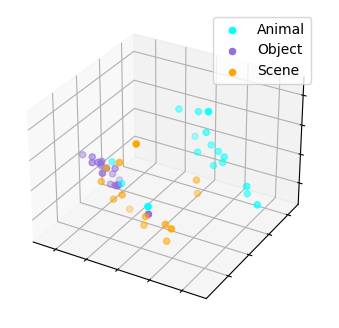

In [52]:
# cat classification imgs
from os.path import join as pjoin
from sklearn.cluster import KMeans
import numpy as np
import glob
import os
import sys
import pandas as pd
import scipy.io as scio
# from sklearn.manifold import MDS
# from sklearn.decomposition import PCA
from tqdm import *
import matplotlib.pyplot as plt


sys.path.append(pjoin(os.pardir, os.pardir, 'external_libraries'))

outdir_ = pjoin(basedir, r'property_analysis/derivatives/2_pro_relation')
ind = scio.loadmat(pjoin(outdir_, f'index_1854to720.mat'))
ind_1854to720 = ind['index_1854to720'][0].squeeze().tolist()
#label
obj_tsv=pjoin(basedir, r'THINGS_stimuli/THINGS',f'things_concepts.tsv')
obj_df = pd.read_csv(obj_tsv, sep='\t')['Word'].tolist()
obj_df_720 = np.array(obj_df)[ind_1854to720].tolist()
# property space
obj_pro_pcs_ = scio.loadmat(pjoin(outdir_, f'obj_pro_pcs.mat'))
obj_pro_pcs__ = obj_pro_pcs_['obj_pro_pcs']
obj_pro_pcs = obj_pro_pcs__[ind_1854to720,:3] #(720,3)

cat1 = ['watch', 'snake', 'hamster', 'platypus', 'face', 'grasshopper', 'dolphin', 'fish', 'gargoyle', 'kimono','sloth', 'whale', 'manatee', 'snail', 'girl', 'toucan', 'lobster']
cat2 = ['lock', 'pliers', 'projector', 'waffle iron', 'mosquito net', 'wrench', 'kite', 'broom', 'washboard', 'game','face mask', 'dustpan', 'pogo stick', 'bracket', 'playing card', 'stair', 'scanner']
cat3 = ['pogo stick', 'pothole', 'hovercraft', 'stalagmite', 'trap', 'railing', 'bench', 'ladder', 'hedge','hammock', 'submarine', 'tarp', 'carousel', 'solar panel'] 
img_nm = cat1+cat2+cat3
target_cats = [['animal',cat1],['object',cat2],['scene',cat3]]

col1, col2 ,col3 = 'cyan','mediumpurple','orange'

cat_pcs = []
for i in range(len(target_cats)):
    cat_idx_ = []
    for j in range(len(target_cats[i][1])):
        cat_idx_.append(obj_df_720.index(target_cats[i][1][j]))
    cat_pcs.append(obj_pro_pcs[cat_idx_])
    

cat1_ = cat_pcs[0]
cat2_ = cat_pcs[1]
cat3_ = cat_pcs[2]

plt.figure(figsize=(5,4))
plt.rc('font',family='Arial', size=10)
ax = plt.axes(projection="3d")
ax.scatter(cat1_[:,0],cat1_[:,1],cat1_[:,2], color=col1, label='Animal')
ax.scatter(cat2_[:,0],cat2_[:,1],cat2_[:,2], color=col2, label='Object')
ax.scatter(cat3_[:,0],cat3_[:,1],cat3_[:,2], color=col3, label='Scene')


# ax.set(xlabel='PC1',ylabel='PC2',zlabel='PC3')
# plt.title("img categories in prop pcs space")
ax.set(xticklabels=[],
       yticklabels=[],
       zticklabels=[])
# 显示图形
plt.legend(loc='upper right')
plt.show()


### model weights

In [ ]:
# prop pcs in flated cortex is done
# see plot_prop_pcs_result.py

In [40]:
#11111111111111111 3D prop pcs map (infalted)
# failed, because 3d color map can't show two sides of each prop

from surfplot import Plot
import nibabel as nib

subject = 'S3'
bg_dir = pjoin(basedir, r'THINGS_fMRI/pycortex_filestore', subject)
infl = pjoin(bg_dir, 'surfaces', f'inflated_lh.gii')
infr = pjoin(bg_dir, 'surfaces', f'inflated_rh.gii')

path_ref_gii = infl
metric_ref = nib.load(path_ref_gii) # 加载输入数据
loca = metric_ref.agg_data() # 获取脑区的顶点位置
numl = loca[0].shape[0] # 左脑顶点个数
# print(numl)

sub = '03'
fdir = pjoin(basedir, r'animacy_analysis\derivatives\3_pro_representation\linear model','sub-'+sub, 'prop_pcs')
outdir = pjoin(fdir, 'plot')
perf_r = np.load(pjoin(fdir, f'perf_r.npz'))
vertex_map = perf_r['perf_r']
vertex_map[vertex_map<0.05] = np.nan

p = Plot(surf_lh=infl, surf_rh=infr,zoom=1.2, views=['lateral','ventral'], brightness=0.8)
# p.add_layer({'left': bg_m1, 'right': bg_m2}, cmap='binary_r', cbar=False)
p.add_layer({'left': vertex_map[:numl], 'right': vertex_map[numl:]}, cmap='hot', color_range=(0,np.max(np.nan_to_num(vertex_map))))
# cmap='YlOrBr_r'
fig = p.build()
# show figure, as you typically would with matplotlib
fig.show()

plt.savefig(pjoin(outdir, f'perf_r.png'),dpi=300, transparent = True)
plt.close()

# add some ROIs on surface plot

C:\Users\qdzhao\AppData\Local\Temp\ipykernel_6304\1015912404.py:31: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


In [41]:
prop_wei = np.load(pjoin(fdir, f'prop_weight.npz'))
pro_nm = ['pc1', 'pc2', 'pc3', 'pc4', 'pc5']
for p in range(3):
    pnm = pro_nm[p]+'_wei'
    vertex_map = prop_wei[pnm]
#     r = np.maximum(-np.min(vertex_map),np.max(vertex_map))
    r = 0.003
    vertex_map[np.argwhere((vertex_map<0.0005) & (vertex_map>-0.0005))] = np.nan
    
    p = Plot(surf_lh=infl, surf_rh=infr, zoom=1.2, views=['lateral','ventral'],brightness=0.8)
    # p.add_layer({'left': bg_m1, 'right': bg_m2}, cmap='binary_r', cbar=False)
    p.add_layer({'left': vertex_map[:numl], 'right': vertex_map[numl:]}, cmap='seismic',color_range=(-r,r)) #BuBkRd in pycortex
    kws={'decimals':5}
    fig = p.build(cbar_kws=kws) 
    plt.savefig(pjoin(outdir, pnm+'.png'),dpi=300, transparent = True)
    plt.close()

### brain voxel prediction accuracy and significance

<KeysViewHDF5 ['adj_p', 'mask', 'trial_sum_all']>
<KeysViewHDF5 ['R', 'X_pred', 'betas_test']>
cor_r count is:  5051


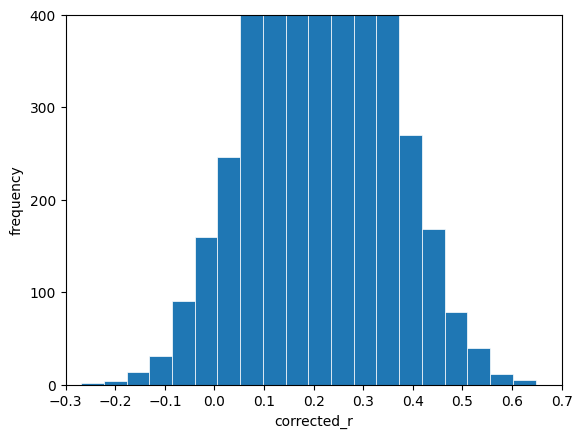

cor_r count is:  3304


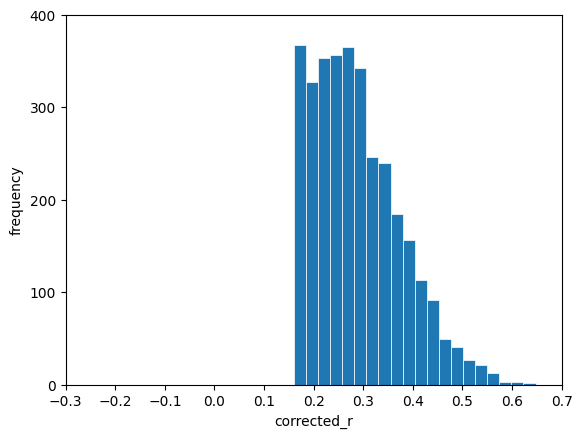

In [11]:
import h5py
import numpy as np
import math
import matplotlib.pyplot as plt
from os.path import join as pjoin
from nilearn.masking import apply_mask, unmask

basedir = r'/n02dat01/users/qdzhao/THINGS'
sub = '01'
f_dir = pjoin(basedir, r'property_analysis/derivatives/linear_model','sub-'+sub)
# p value of training set
adjp_f = pjoin(f_dir, 'prop_pcs', f'cross_validation_permutation_result.mat')
adjp = h5py.File(adjp_f)
print(adjp.keys())
adjp_ = adjp['adj_p']
adj_p = np.squeeze(adjp_)

cor_f = pjoin(f_dir, 'prop_pcs', f'model_test_result.mat')
corf = h5py.File(cor_f)
print(corf.keys())
cor_ = corf['R']
cor = np.squeeze(cor_) # r value

# significant r with p < .05
cor_r1 = []
cor_r2 = []
for j in range(len(adj_p)):
    if adj_p[j]<0.05:
        cor_r1.append(cor[j])
    if adj_p[j]<0.05 and cor[j]>0.16:
        cor_r2.append(cor[j])

# plot:
fig, ax = plt.subplots()
cor_r = np.array(cor_r1)
print('cor_r count is: ',len(cor_r))
ax.hist(cor_r, bins=20, linewidth=0.5, edgecolor="white")

ax.set(xlim=(-0.3, 0.7), xticks=np.linspace(-0.3, 0.7, 11),
       ylim=(0, 400), yticks=np.linspace(0, 400, 5))
plt.xlabel('corrected_r')
plt.ylabel('frequency')
plt.show()

fig, ax = plt.subplots()
cor_r = np.array(cor_r2)
print('cor_r count is: ',len(cor_r))
ax.hist(cor_r, bins=20, linewidth=0.5, edgecolor="white")

ax.set(xlim=(-0.3, 0.7), xticks=np.linspace(-0.3, 0.7, 11),
       ylim=(0, 400), yticks=np.linspace(0, 400, 5))
plt.xlabel('corrected_r')
plt.ylabel('frequency')
plt.show()
plt.close()

# 这是个问题，脑上的结果也是，校正后的q区域在测试集上也存在负的r值。
# 可能的原因是 测试集和训练集的分布不一致

In [12]:
# 下面分析训练集上可显著预测的区域的r值分布
# 然后将该r的最小值作为 model performance的阈值。
import scipy.io as scio

# real brain activation
datdir = pjoin(basedir, r'property_analysis/derivatives/linear_model/data','sub-'+sub)

brain_act = scio.loadmat(pjoin(datdir, f'betas_concept_v2.mat')) # 'betas_train':betas_train(648,V),'betas_test':betas_test(72,V)
prop_pcs = scio.loadmat(pjoin(datdir, f'obj720_pro_pcs.mat')) # 'prop_train':prop_train(648,5),'prop_test':prop_test(72,5)
br_act_tr = brain_act['betas_train']
print(br_act_tr.shape)
prp_pcs_tr = prop_pcs['prop_train']
print(prp_pcs_tr.shape)

# predicted brain activation
f_dir = pjoin(basedir, r'property_analysis/derivatives/linear_model','sub-'+sub)

wei_f = pjoin(f_dir, 'prop_pcs','encoding_training_result.mat')
weif = h5py.File(wei_f) # encoding weight
print(weif.keys())
wei_ = weif['thetaFinal']
wei = np.squeeze(wei_)
print(wei.shape) #(V,5)

# corr (real, prdicted)
br_act_tr_pred = np.dot(prp_pcs_tr,wei.T)

# sigf mask
# p value of training set
adjp_f = pjoin(f_dir, 'prop_pcs', f'cross_validation_permutation_result.mat')
adjp = h5py.File(adjp_f)
print(adjp.keys())
adjp_ = adjp['adj_p']
adj_p = np.squeeze(adjp_)

# significant r with p < .05
idx_adjp = []
for j in range(len(adj_p)):
    if adj_p[j]<0.05:
        idx_adjp.append(j)

corr = []
x = br_act_tr.T[idx_adjp]
y = br_act_tr_pred.T[idx_adjp]
for i in range(len(idx_adjp)):
    tmp_r = np.corrcoef(x[i],y[i])[0,1]
    corr.append(tmp_r)
corr = np.array(corr)
print(np.max(corr))
print(np.min(corr))

# threshold for test set is 0.163 for sub-01, 0.165 for sub-02, 0.167 for sub-03

(648, 211339)
(648, 5)
<KeysViewHDF5 ['CV', 'reguFinal', 'thetaFinal', 'thetaRecord', 'validSquaError']>
(211339, 5)
<KeysViewHDF5 ['adj_p', 'mask', 'trial_sum_all']>
0.5789535989462666
0.16306307792357244


cor_r count is:  5051


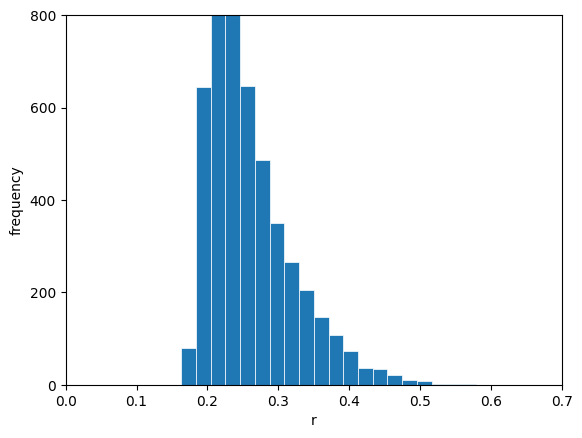

In [13]:
fig, ax = plt.subplots()
print('cor_r count is: ',len(corr))
ax.hist(corr, bins=20, linewidth=0.5, edgecolor="white")

ax.set(xlim=(0, 0.7), xticks=np.linspace(0, 0.7, 8),
       ylim=(0, 800), yticks=np.linspace(0, 800, 5))
plt.xlabel('r')
plt.ylabel('frequency')
plt.show()
plt.close()

In [13]:
### sig voxel dis in eraly visual and higher visual cortex

import h5py
import numpy as np
import math
import matplotlib.pyplot as plt
from os.path import join as pjoin
from nilearn.masking import apply_mask, unmask

basedir = r'/n02dat01/users/qdzhao/THINGS'
sub = '03'
bmask_dir = pjoin(basedir, r'THINGS_fMRI/brainmasks')
bmask_f = pjoin(bmask_dir, f'sub-{sub}_space-T1w_brainmask.nii.gz')

f_dir = pjoin(basedir, r'property_analysis/derivatives/linear_model','sub-'+sub)
# p value of training set
adjp_f = pjoin(f_dir, 'prop_pcs', f'cross_validation_permutation_result.mat')
adjp = h5py.File(adjp_f)
print(adjp.keys())
adjp_ = adjp['adj_p']
adj_p = np.squeeze(adjp_)

cor_f = pjoin(f_dir, 'prop_pcs', f'model_test_result.mat')
corf = h5py.File(cor_f)
print(corf.keys())
cor_ = corf['R']
cor = np.squeeze(cor_) # r value

# significant r with p < .05
corr = np.zeros(len(adj_p))

for j in range(len(adj_p)):
    if adj_p[j]<0.05 and cor[j]>0.05:
        corr[j] = 1

# apply roi masks on corr
corr_img = unmask(corr, bmask_f)
corr_roi = []
roi = ['EV','hV4','Animal','Object','Scene']

mask_dir1 = pjoin(basedir, r'THINGS_fMRI/rois/rois/prf')
mask_f = pjoin(mask_dir1, f'sub-{sub}/EV_mask.nii.gz')
corr_roi.append(np.sum(apply_mask(corr_img, mask_f))) # get early visual roi

mask_f = pjoin(mask_dir1, f'sub-{sub}/MV_hV4_mask.nii.gz')
corr_roi.append(np.sum(apply_mask(corr_img, mask_f))) # get early visual roi

mask_dir2 = pjoin(basedir, r'THINGS_fMRI/rois/rois/category_localizer')
mask_f = pjoin(mask_dir2, 'sub-'+sub,f'Fa_mask.nii.gz')
fa_sum = np.sum(apply_mask(corr_img, mask_f)) # get higher visual roi

mask_f = pjoin(mask_dir2, 'sub-'+sub,f'Bd_mask.nii.gz')
corr_roi.append(fa_sum + np.sum(apply_mask(corr_img, mask_f))) # get higher visual roi

mask_f = pjoin(mask_dir2, 'sub-'+sub,f'Ob_mask.nii.gz')
corr_roi.append(np.sum(apply_mask(corr_img, mask_f))) # get higher visual roi

mask_f = pjoin(mask_dir2, 'sub-'+sub,f'Sc_mask.nii.gz')
corr_roi.append(np.sum(apply_mask(corr_img, mask_f))) # get higher visual roi

<KeysViewHDF5 ['adj_p', 'mask', 'trial_sum_all']>
<KeysViewHDF5 ['R', 'X_pred', 'betas_test']>


In [ ]:
# run only once
corr_roi_group = []

In [14]:
corr_roi_group.append(np.array(corr_roi)/np.sum(corr))

In [16]:
corr_roi_group = np.array(corr_roi_group)
print(corr_roi_group.shape)
mean_corr = np.mean(corr_roi_group, axis = 0)
print(mean_corr)
var_corr = np.var(corr_roi_group, axis = 0)
print(var_corr)
std_corr = np.std(corr_roi_group, axis = 0)
print(std_corr)

(3, 5)
[0.04506819 0.03709235 0.13864036 0.13390786 0.09266095]
[5.47798243e-05 3.33813996e-04 3.39037067e-04 4.12537842e-03
 7.46076632e-05]
[0.00740134 0.01827058 0.01841296 0.06422911 0.00863757]


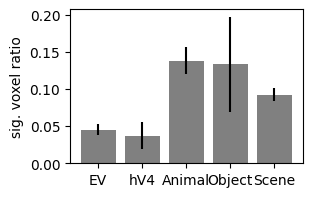

In [17]:
plt.figure(figsize=(3,2)) #,dpi=300
x = np.arange(len(corr_roi))
plt.bar(x,mean_corr,yerr=std_corr,color="gray")
plt.xticks(x,labels=roi)
plt.ylabel('sig. voxel ratio')
# plt.title('ROI prop selection')
# plt.legend(loc="best")
plt.show()

In [42]:
import h5py
import numpy as np
import math
import matplotlib.pyplot as plt
from os.path import join as pjoin
from nilearn.masking import apply_mask, unmask

basedir = r'/n02dat01/users/qdzhao/THINGS'
sub = '01'
f_dir = pjoin(basedir, r'property_analysis/derivatives/linear_model','sub-'+sub)
# p value of training set
adjp_f = pjoin(f_dir, 'prop_pcs', f'cross_validation_permutation_result.mat')
adjp = h5py.File(adjp_f)
print(adjp.keys())
adjp_ = adjp['adj_p']
adj_p = np.squeeze(adjp_)

cor_f = pjoin(f_dir, 'prop_pcs', f'model_test_result.mat')
corf = h5py.File(cor_f)
print(corf.keys())
cor_ = corf['R']
cor = np.squeeze(cor_) # r value

# prop pcs selection of each voxel in each ROI
wei_f = pjoin(f_dir, 'prop_pcs','encoding_training_result.mat')
weif = h5py.File(wei_f) # encoding weight
print(weif.keys())
wei_ = weif['thetaFinal']
wei = np.squeeze(wei_)
print(wei.shape) #(V,5)

wei_s = [] # significant voxels
mask_s = []
for j in range(len(adj_p)):
    if adj_p[j]<0.05 and cor[j]>0.05:
        wei_s.append(wei[j,:3])
        mask_s.append(j)
wei_s = np.array(wei_s)

<KeysViewHDF5 ['adj_p', 'mask', 'trial_sum_all']>
<KeysViewHDF5 ['R', 'X_pred', 'betas_test']>
<KeysViewHDF5 ['CV', 'reguFinal', 'thetaFinal', 'thetaRecord', 'validSquaError']>
(211339, 5)


(3, 3)


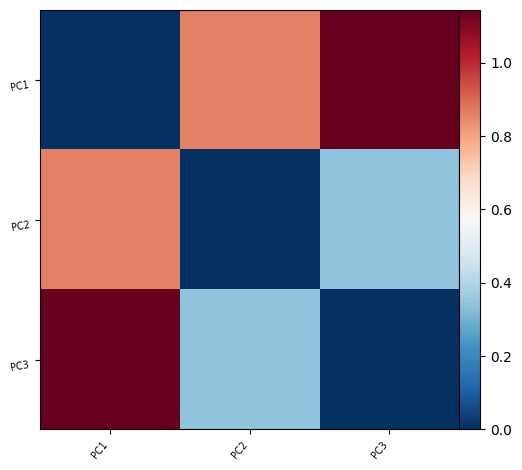

[[ 1.          0.13883505 -0.14363056]
 [ 0.13883505  1.          0.65710907]
 [-0.14363056  0.65710907  1.        ]]


In [82]:
# PC RDM on brain
pc_rdm_brain = rdm_cal_plot(wei_s[:,:3].T)
print(1-pc_rdm_brain)

(4510, 3)


<Figure size 800x400 with 0 Axes>

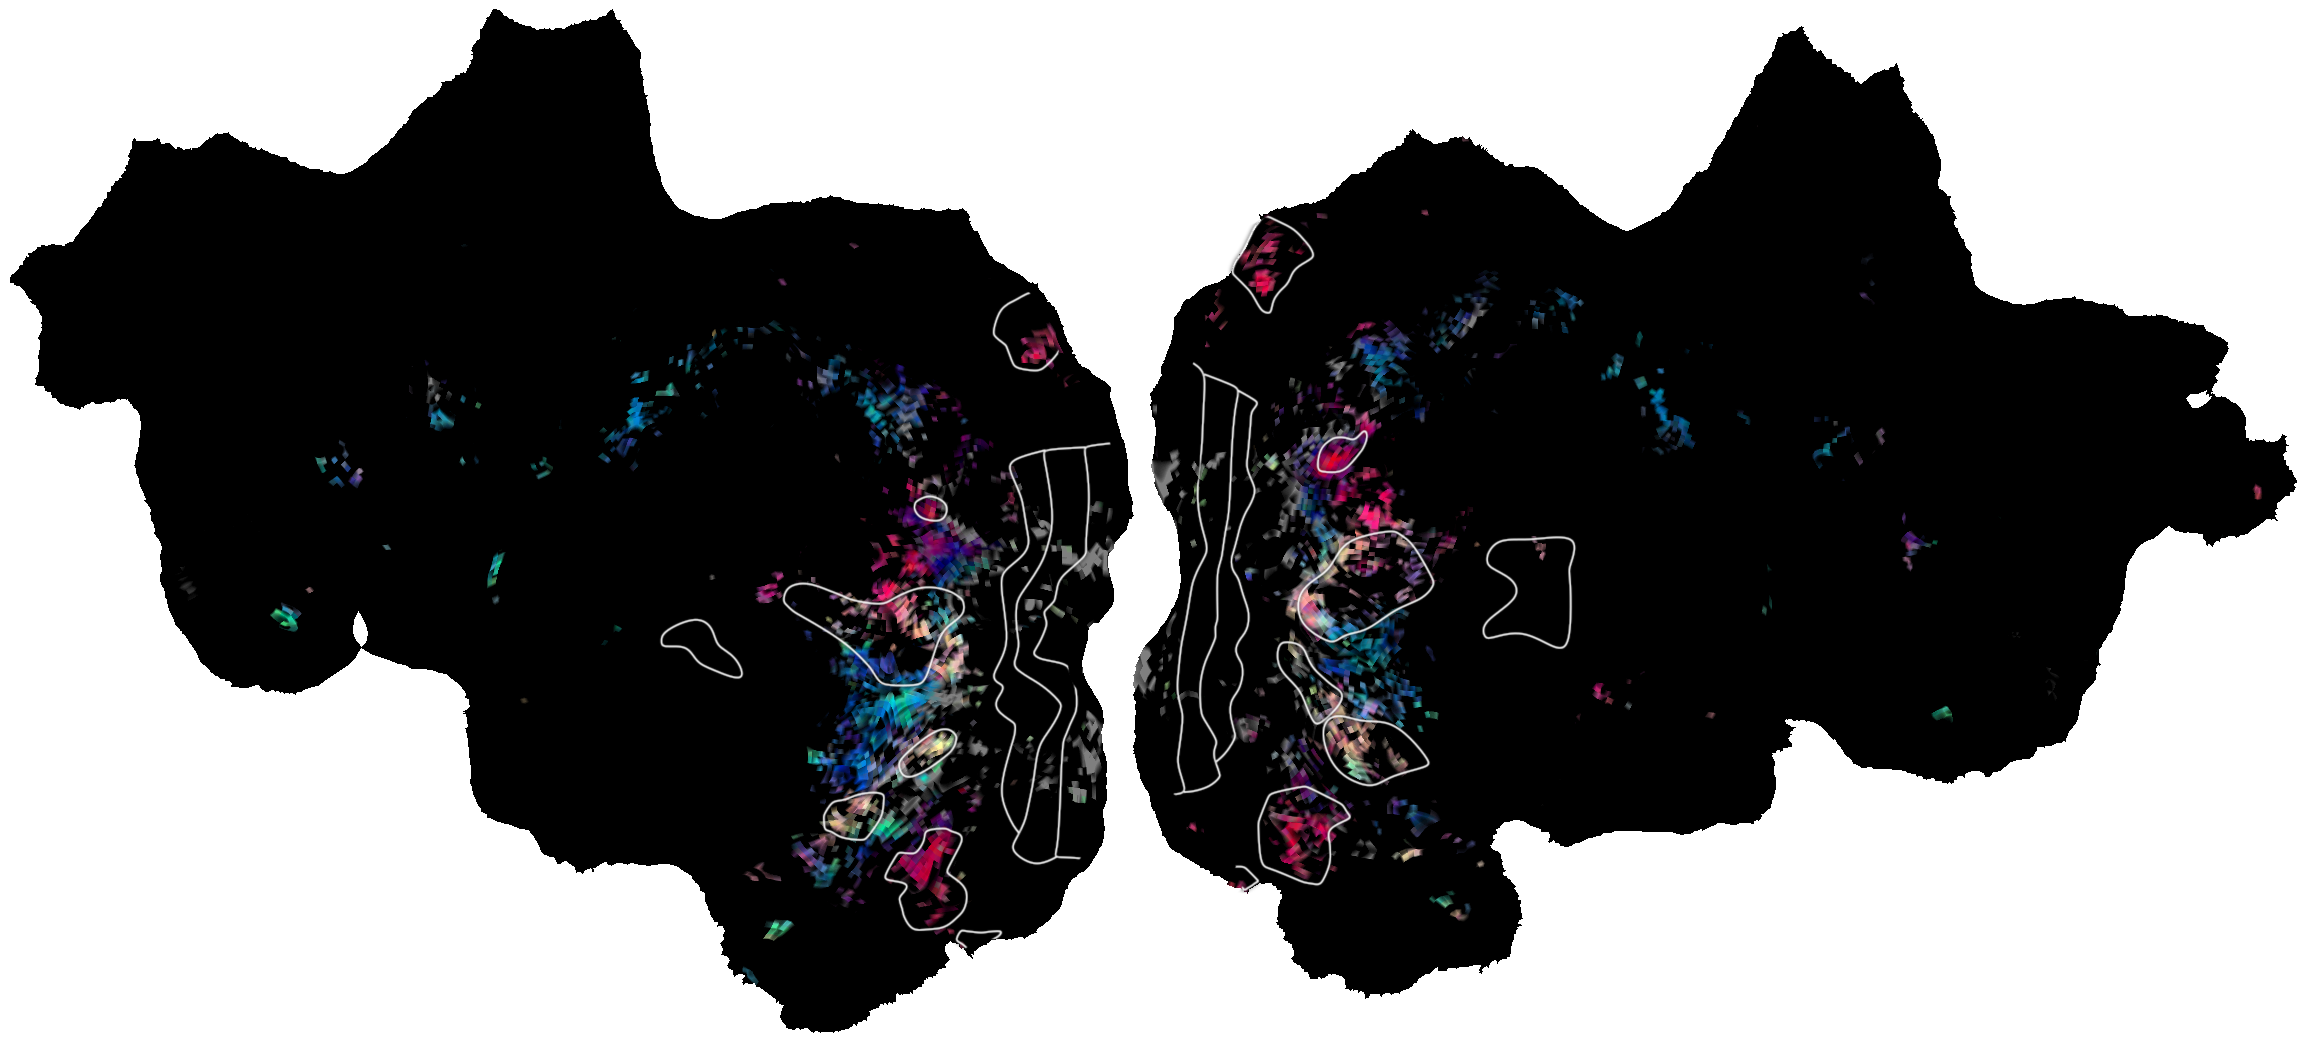

In [40]:
# plot 3d pc wei map
import cortex
from nilearn.image import load_img
from nilearn.masking import apply_mask, unmask

# basic dir
result_dir = pjoin(basedir, r'property_analysis/derivatives/linear_model', 'sub-'+sub)

bmask_dir = pjoin(basedir, r'THINGS_fMRI/brainmasks')
bmask_f = pjoin(bmask_dir, f'sub-{sub}_space-T1w_brainmask.nii.gz')

def plot_3d(data, fname):
    subject = "S1"
    xfm = "align_auto"
    # Scaling the three datasets to be between 0-255
    data[0] = data[0] + np.abs(np.min(data[0]))
    test1_scaled = data[0] / np.max(data[0]) * 255
    data[1] = data[1] + np.abs(np.min(data[1]))
    test2_scaled = data[1] / np.max(data[1]) * 255
    data[2] = data[2] + np.abs(np.min(data[2]))
    test3_scaled = data[2] / np.max(data[2]) * 255
    
    # Creating three cortex.Volume objects with the test data as np.uint8
    #red = cortex.Volume(test1_scaled.astype(np.uint8), 'S1', 'align_auto')
    red = cortex.Volume(test1_scaled.astype(np.uint8), subject, xfm)
    green = cortex.Volume(test2_scaled.astype(np.uint8), subject, xfm)
    blue = cortex.Volume(test3_scaled.astype(np.uint8), subject, xfm)
    
    # This creates an RGB Volume from the three different color channels for
    # this subject using custom colors, and shared value ranges.
    # Note that you do not need to specify the transform when creating this as it
    # is already specified in the red, green, and blue channels
    vol_data = cortex.VolumeRGB(red, green, blue, subject)
    
    fig = plt.figure(figsize=(8,4))
    roi_lists=['V1','V2','V3','OFA','FFA','pSTS','EBA','PPA','OPA','MPA','LOC']
    cortex.quickshow(vol_data, with_colorbar=False, roi_list=roi_lists, with_labels=False)
    plt.show()
    plt.savefig(pjoin(result_dir, r'prop_pcs/plot', str(fname) + '.jpg'), dpi=300)
    plt.close(fig)


# load the model result
print(wei_s.shape) # (v_,3)
ma = 0.003
wei_s_ = np.zeros([len(adj_p),3])-ma
# wei_s_[mask_s] = np.abs(wei_s)*1000
wei_s_[mask_s] = wei_s

wei_3d = []
for i in range(3):
    weigh_mrx_i = np.squeeze(wei_s_[:,i])
    #wei_i_ = np.where(adj_p_>1.3, weigh_mrx_i, 0)
    wei_i_ = weigh_mrx_i
    wei_img = unmask(wei_i_, bmask_f)
    wei_3dimg = np.swapaxes(load_img(wei_img).get_fdata(), 0, -1)
    wei_3d.append(wei_3dimg)

ma = 0.003
wei_3d = np.array(wei_3d)
wei_3d[wei_3d > ma] = ma
wei_3d[wei_3d < -ma] = -ma
fnm = 'prop_pcs_3d'
plot_3d(wei_3d, fnm)





pc1 and pc2 correlation  PearsonRResult(statistic=0.13883505371996818, pvalue=7.498552336205833e-21)


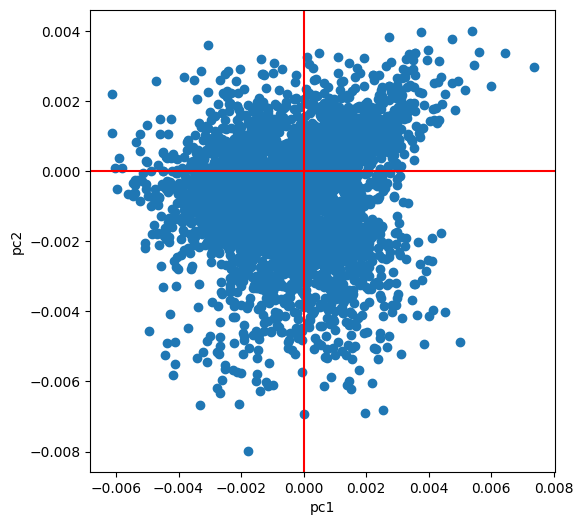

pc1 and pc3 correlation  PearsonRResult(statistic=-0.1436305645056341, pvalue=3.217810198643188e-22)


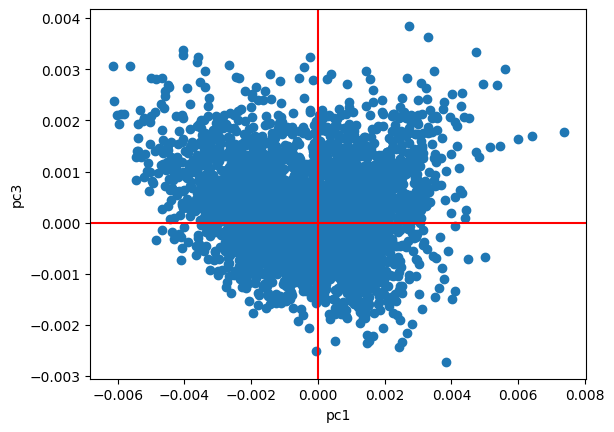

pc2 and pc3 correlation  PearsonRResult(statistic=0.6571090717202753, pvalue=0.0)


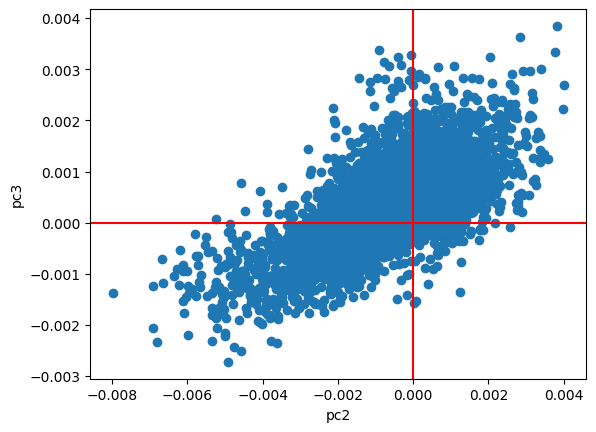

In [2]:
#2222222222222222 prop pcs cluster
from scipy.stats import pearsonr

idx = []
wei_s = [] # significant voxels
for j in range(len(adj_p)):
    if adj_p[j]<0.05 and cor[j]>0.05:
        idx.append(j)
        wei_s.append(wei[j,:3])
wei_s = np.array(wei_s)

# voxel disttribution in prop pcs space
r12 = pearsonr(wei_s[:,0], wei_s[:,1])
print('pc1 and pc2 correlation ',r12)
plt.figure(figsize=(6, 6))
plt.scatter(wei_s[:,0], wei_s[:,1])
plt.axhline(0, c='r') # 画出 x=0 这条水平线
plt.axvline(0, c='r') # 画出 y=0 这条垂直线
plt.xlabel('pc1')
plt.ylabel('pc2')
plt.show()

r13 = pearsonr(wei_s[:,0], wei_s[:,2])
print('pc1 and pc3 correlation ',r13)
plt.scatter(wei_s[:,0], wei_s[:,2])
plt.axhline(0, c='r')
plt.axvline(0, c='r')
plt.xlabel('pc1')
plt.ylabel('pc3')
plt.show()

r23 = pearsonr(wei_s[:,1], wei_s[:,2])
print('pc2 and pc3 correlation ',r23)
plt.scatter(wei_s[:,1], wei_s[:,2])
plt.axhline(0, c='r')
plt.axvline(0, c='r')
plt.xlabel('pc2')
plt.ylabel('pc3')
plt.show()

### 聚类分析在surface数据上进行，但又涉及到volume上ROI分析，故将volume数据也聚成三类

In [ ]:
# you only run once
from sklearn.cluster import KMeans

x_true = wei_s #(u, 3)
clf = KMeans(3)
yhat = clf.fit_predict(x_true)
# np.savez(pjoin(f_dir,'prop_pcs','volume_pc_clu_label3.npz'),label = yhat)

/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f2a78a1f790>
Traceback (most recent call last):
  File "/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get

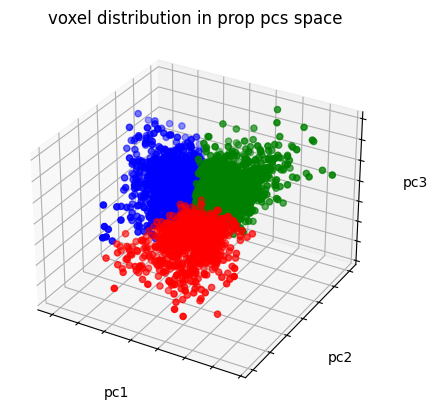

In [6]:
yhat_ = np.load(pjoin(f_dir,'prop_pcs','volume_pc_clu_label3.npz'))
yhat = yhat_['label']

clu1 = []
clu2 = []
clu3 = []

for i in range(len(yhat)):
    if yhat[i]==0:
        clu1.append(wei_s[i])
    if yhat[i]==1:
        clu2.append(wei_s[i])
    if yhat[i]==2:
        clu3.append(wei_s[i])

clu1 = np.array(clu1)
clu2 = np.array(clu2)
clu3 = np.array(clu3)

ax = plt.axes(projection="3d")
ax.scatter(clu1[:,0],clu1[:,1],clu1[:,2], c="g")
ax.scatter(clu2[:,0],clu2[:,1],clu2[:,2], c="r")
ax.scatter(clu3[:,0],clu3[:,1],clu3[:,2], c="b")
# sub-01 =[g,r,b], sub02=[r,b,o,g], sub03=[o,r,b,g]

ax.set(xlabel='pc1',ylabel='pc2',zlabel='pc3')
plt.title("voxel distribution in prop pcs space")
ax.set(xticklabels=[],
       yticklabels=[],
       zticklabels=[])
# show plot
plt.show()


findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


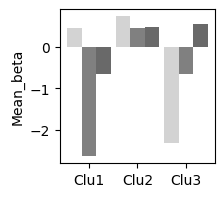

In [43]:
# prop selection in each cluster
yhat_ = np.load(pjoin(f_dir,'prop_pcs','volume_pc_clu_label3.npz'))
yhat = yhat_['label']

wei_clu1 = []
wei_clu2 = []
wei_clu3 = []

for i in range(wei_s.shape[0]):
    if yhat[i] == 0:
        wei_clu1.append(wei_s[i])
    if yhat[i] == 1:
        wei_clu2.append(wei_s[i])
    if yhat[i] == 2:
        wei_clu3.append(wei_s[i]) # (v_,3)

wei_clu1_col = np.mean(np.array(wei_clu1),axis=0)*1000 # (3,)
wei_clu1_col_std = np.std(np.array(wei_clu1),axis=0)*1000
wei_clu2_col = np.mean(np.array(wei_clu2),axis=0)*1000
wei_clu2_col_std = np.std(np.array(wei_clu2),axis=0)*1000
wei_clu3_col = np.mean(np.array(wei_clu3),axis=0)*1000
wei_clu3_col_std = np.std(np.array(wei_clu3),axis=0)*1000

wei_clu_col = [] # volume clus [2,1,3] match surface clu [1,2,3]
wei_clu_col.append(wei_clu2_col)
wei_clu_col.append(wei_clu1_col)
wei_clu_col.append(wei_clu3_col)
wei_clu_col = np.array(wei_clu_col)

wei_clu_col_std = [] # volume clus [2,1,3] match surface clu [1,2,3]
wei_clu_col_std.append(wei_clu2_col_std)
wei_clu_col_std.append(wei_clu1_col_std)
wei_clu_col_std.append(wei_clu3_col_std)
wei_clu_col_std = np.array(wei_clu_col_std)

xlb = ['Clu1', 'Clu2', 'Clu3']
x = np.arange(len(xlb))
width = 0.3
ly2 = x - width
ly3 = x
ly4 = x + width

plt.figure(figsize=(2,2)) # ,dpi=300
plt.rc('font',family='Arial', size=10)
# plt.bar(ly2,wei_clu_col.T[0],width=width,yerr=wei_clu_col_std.T[0],color="orange",label='PC1')
# plt.bar(ly3,wei_clu_col.T[1],width=width,yerr=wei_clu_col_std.T[1],color="cyan",label='PC2')
# plt.bar(ly4,wei_clu_col.T[2],width=width,yerr=wei_clu_col_std.T[2],color="mediumpurple",label='PC3')

plt.bar(ly2,wei_clu_col.T[0],width=width,color='lightgrey',label='PC1') # "orange" "cyan" "mediumpurple"
plt.bar(ly3,wei_clu_col.T[1],width=width,color='grey',label='PC2')
plt.bar(ly4,wei_clu_col.T[2],width=width,color='dimgrey',label='PC3')

font_dict = {'family':'Arial', 'size':10}
plt.xticks(x,labels=xlb,fontproperties=font_dict)
# plt.xlabel('Cluster',fontdict=font_dict)
plt.ylabel('Mean_beta',fontdict=font_dict)
# plt.legend(loc='best',prop=font_dict)
# plt.title('ROI prop selection')
plt.show()
plt.close()

In [29]:
print(wei_clu3_col)
print(wei_clu_col)
print(wei_clu_col[0])

[-3.57617684 -1.00360237  0.86448584]
[[ 0.49219202 -2.78208733 -0.68499598]
 [ 1.41026252  0.86083223  0.90992258]
 [-3.57617684 -1.00360237  0.86448584]]
[ 0.49219202 -2.78208733 -0.68499598]


In [40]:
# cluster 1-3 ratio in each cat regions

import h5py
import numpy as np
import math
import matplotlib.pyplot as plt
from os.path import join as pjoin
from nilearn.masking import apply_mask, unmask

def count_lb(x):
    lb1 = 0
    lb2 = 0
    lb3 = 0
    for i in range(x.shape[0]):
        if x[i] == 0:
            lb1 = lb1+1
        if x[i] == 1:
            lb2 = lb2+1
        if x[i] == 2:
            lb3 = lb3+1
    return np.array([lb1,lb2,lb3])
        
basedir = r'/n02dat01/users/qdzhao/THINGS'
sub = '03'
f_dir = pjoin(basedir, r'property_analysis/derivatives/linear_model','sub-'+sub)
# p value of training set
adjp_f = pjoin(f_dir, 'prop_pcs', f'cross_validation_permutation_result.mat')
adjp = h5py.File(adjp_f)
print(adjp.keys())
adjp_ = adjp['adj_p']
adj_p = np.squeeze(adjp_)

cor_f = pjoin(f_dir, 'prop_pcs', f'model_test_result.mat')
corf = h5py.File(cor_f)
print(corf.keys())
cor_ = corf['R']
cor = np.squeeze(cor_) # r value

yhat_ = np.load(pjoin(f_dir,'prop_pcs','volume_pc_clu_label3.npz'))
yhat = yhat_['label']

idx = []
yhat_ = np.zeros(len(adj_p), dtype=int)-1 # cluster label of all voxel
for j in range(len(adj_p)):
    if adj_p[j]<0.05 and cor[j]>0.05:
        idx.append(j)
yhat_[idx] = yhat



# apply roi masks on corr
bmask_dir = pjoin(basedir, r'THINGS_fMRI/brainmasks')
bmask_f = pjoin(bmask_dir, f'sub-{sub}_space-T1w_brainmask.nii.gz')
yhat_img = unmask(yhat_, bmask_f)
clu_roi = []
roi = ['Scene','Animal','Object']

mask_dir2 = pjoin(basedir, r'THINGS_fMRI/rois/rois/category_localizer')
mask_f = pjoin(mask_dir2, 'sub-'+sub,f'Sc_mask.nii.gz')
clu_roi.append(count_lb(apply_mask(yhat_img, mask_f))) # get higher visual roi

mask_f = pjoin(mask_dir2, 'sub-'+sub,f'Fa_mask.nii.gz')
fa_lb = count_lb(apply_mask(yhat_img, mask_f)) # get higher visual roi

mask_f = pjoin(mask_dir2, 'sub-'+sub,f'Bd_mask.nii.gz')
clu_roi.append(fa_lb + count_lb(apply_mask(yhat_img, mask_f))) # get higher visual roi

mask_f = pjoin(mask_dir2, 'sub-'+sub,f'Ob_mask.nii.gz')
clu_roi.append(count_lb(apply_mask(yhat_img, mask_f))) # get higher visual roi
clu_roi = np.array(clu_roi)


<KeysViewHDF5 ['adj_p', 'mask', 'trial_sum_all']>
<KeysViewHDF5 ['R', 'X_pred', 'betas_test']>


In [1]:
import numpy as np

clu_roi_1 = np.array([[27,329,7],[537,24,94],[582,33,374]])
clu_roi_1 = clu_roi_1.T[[1,0,2]].T
print(clu_roi_1)
clu_roi_2 = np.array([[326,61,13],[5,137,489],[3,235,236]])
clu_roi_2 = clu_roi_2.T[[0,2,1]].T
print(clu_roi_2)
clu_roi_3 = np.array([[225,0,0],[37,178,46],[23,27,98]])
clu_roi_3 = clu_roi_3.T[[0,1,2]].T
print(clu_roi_3)

clu_roi_ = np.array([clu_roi_1,clu_roi_2,clu_roi_3])
clu_roi = np.mean(clu_roi_, axis=0)
clu_roi_std = np.std(clu_roi_, axis=0)
print(clu_roi)
print(clu_roi_std)

[[329  27   7]
 [ 24 537  94]
 [ 33 582 374]]
[[326  13  61]
 [  5 489 137]
 [  3 236 235]]
[[225   0   0]
 [ 37 178  46]
 [ 23  27  98]]
[[293.33333333  13.33333333  22.66666667]
 [ 22.         401.33333333  92.33333333]
 [ 19.66666667 281.66666667 235.66666667]]
[[ 48.33448274  11.02522361  27.25598813]
 [ 13.1402689  159.13167155  37.16928242]
 [ 12.47219129 228.86725896 112.67751427]]


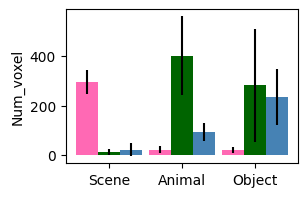

In [53]:
# print(clu_roi)

xlb = roi
x = np.arange(len(xlb))
width = 0.3
ly2 = x - width
ly3 = x
ly4 = x + width

plt.figure(figsize=(3,2)) # ,dpi=300
plt.rc('font',family='Arial', size=10)
# plt.bar(ly2,clu_roi.T[0],width=width,color="hotpink",label='Clu1')
# plt.bar(ly3,clu_roi.T[1],width=width,color="darkgreen",label='Clu2')
# plt.bar(ly4,clu_roi.T[2],width=width,color="steelblue",label='Clu3')

plt.bar(ly2,clu_roi.T[0],width=width,yerr=clu_roi_std.T[0],color="hotpink",label='Clu1')
plt.bar(ly3,clu_roi.T[1],width=width,yerr=clu_roi_std.T[1],color="darkgreen",label='Clu2')
plt.bar(ly4,clu_roi.T[2],width=width,yerr=clu_roi_std.T[2],color="steelblue",label='Clu3')

font_dict = {'family':'Arial', 'size':10}
plt.xticks(x,labels=xlb,fontproperties=font_dict)
# plt.xlabel('Cluster',fontdict=font_dict)
plt.ylabel('Num_voxel',fontdict=font_dict)
# plt.legend(loc='best',prop=font_dict)
# plt.title('ROI prop selection') 
plt.show()
plt.close()

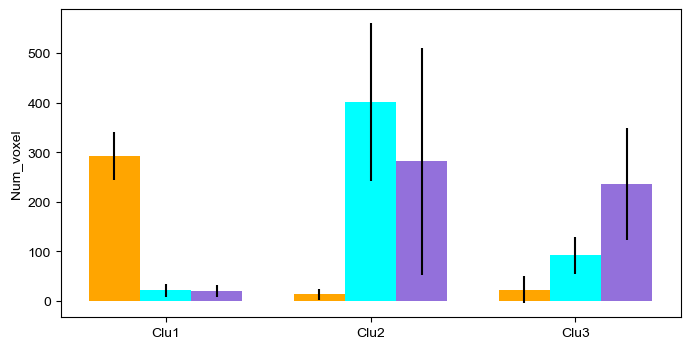

In [6]:
# print(clu_roi)
import matplotlib.pyplot as plt

roi = ['Scene','Animal','Object']
clu = ['Clu1','Clu2','Clu3']
xlb = roi
# x = np.arange(len(xlb))
x = np.array([0,1.2,2.4])
width = 0.3
ly2 = x - width
ly3 = x
ly4 = x + width

plt.figure(figsize=(8,4)) # ,dpi=300
plt.rc('font',family='Arial', size=10)
# plt.bar(ly2,clu_roi.T[0],width=width,color="hotpink",label='Clu1')
# plt.bar(ly3,clu_roi.T[1],width=width,color="darkgreen",label='Clu2')
# plt.bar(ly4,clu_roi.T[2],width=width,color="steelblue",label='Clu3')

plt.bar(ly2,clu_roi[0],width=width,yerr=clu_roi_std[0],color='orange',label=roi[0])
plt.bar(ly3,clu_roi[1],width=width,yerr=clu_roi_std[1],color='cyan',label=roi[1])
plt.bar(ly4,clu_roi[2],width=width,yerr=clu_roi_std[2],color='mediumpurple',label=roi[2])

font_dict = {'family':'Arial', 'size':10}
plt.xticks(x,labels=clu,fontproperties=font_dict)
# plt.xlabel('Cluster',fontdict=font_dict)
plt.ylabel('Num_voxel',fontdict=font_dict)
# plt.legend(loc='best',prop=font_dict)
# plt.title('ROI prop selection') 
plt.show()
plt.close()

In [3]:
# clu prefered imgs
import h5py
import numpy as np
import scipy.io as scio
import matplotlib.pyplot as plt
from os.path import join as pjoin

basedir = r'/n02dat01/users/qdzhao/THINGS'
sub = '01'
f_dir = pjoin(basedir, r'property_analysis/derivatives/linear_model','sub-'+sub)

# prepare brain activation
betas_csv_dir = pjoin(basedir, r'THINGS_fMRI/betas_csv')
betas_concept_ = scio.loadmat(pjoin(betas_csv_dir, f'sub-{sub}_betas_concept.mat'))
betas_concept =  betas_concept_['data'].T # (V,720)
print(betas_concept.shape)

# p value of training set
adjp_f = pjoin(f_dir, 'prop_pcs', f'cross_validation_permutation_result.mat')
adjp = h5py.File(adjp_f)
# print(adjp.keys())
adjp_ = adjp['adj_p']
adj_p = np.squeeze(adjp_)

cor_f = pjoin(f_dir, 'prop_pcs', f'model_test_result.mat')
corf = h5py.File(cor_f)
# print(corf.keys())
cor_ = corf['R']
cor = np.squeeze(cor_) # r value

idx = []
for j in range(len(adj_p)):
    if adj_p[j]<0.05 and cor[j]>0.05:
        idx.append(j)

yhat_ = np.load(pjoin(f_dir,'prop_pcs','volume_pc_clu_label3.npz'))
yhat = yhat_['label']

idx_clu1 = []
idx_clu2 = []
idx_clu3 = []

for i in range(len(yhat)):
    if yhat[i]==0:
        idx_clu1.append(idx[i])
    if yhat[i]==1:
        idx_clu2.append(idx[i])
    if yhat[i]==2:
        idx_clu3.append(idx[i])

betas_clu1 = betas_concept[idx_clu1]
print(betas_clu1.shape)
betas_clu2 = betas_concept[idx_clu2]
print(betas_clu2.shape)
betas_clu3 = betas_concept[idx_clu3]
print(betas_clu3.shape)

(211339, 720)
(1904, 720)
(1055, 720)
(1551, 720)


In [ ]:
# cat selective imgs idx in 1854
import h5py
import pandas as pd
import scipy.io as scio
from os.path import join as pjoin

basedir = r'/n02dat01/users/qdzhao/THINGS'
outdir_ = pjoin(basedir, r'property_analysis/derivatives/2_pro_relation')
ind = scio.loadmat(pjoin(outdir_, f'index_1854to720.mat'))
ind_1854to720 = ind['index_1854to720'][0].squeeze().tolist()

obj_tsv=pjoin(basedir, r'THINGS_stimuli/THINGS',f'things_concepts.tsv')
obj_df = pd.read_csv(obj_tsv, sep='\t')['Word'].tolist()
obj_df_ = np.array(obj_df)[ind_1854to720]
obj_df = obj_df_.tolist()

betas_clu1_mean = np.mean(betas_clu1,axis=0)
# print(betas_clu1_mean.shape) # (720,)
betas_idx1 = np.argsort(-betas_clu1_mean) # np.flip()
obj_df_1 = np.array(obj_df)[betas_idx1].tolist()
print(obj_df_1[:10])

betas_clu2_mean = np.mean(betas_clu2,axis=0)
# print(betas_clu1_mean.shape) # (720,)
betas_idx2 = np.argsort(-betas_clu2_mean) # np.flip()
obj_df_2 = np.array(obj_df)[betas_idx2].tolist()
print(obj_df_2[:10])

betas_clu3_mean = np.mean(betas_clu3,axis=0)
# print(betas_clu1_mean.shape) # (720,)
betas_idx3 = np.argsort(-betas_clu3_mean) # np.flip()
obj_df_3 = np.array(obj_df)[betas_idx3].tolist()
print(obj_df_3[:10])

img_nm = []
num=20
img_nm = obj_df_2[:num]+obj_df_1[:num]+obj_df_3[:num]
print(img_nm)





['otter', 'watch', 'snake', 'hamster', 'footrest', 'pogo stick', 'sloth', 'whale', 'headphones', 'anklet']
['pogo stick', 'stair', 'urinal', 'meat grinder', 'footrest', 'desk', 'pothole', 'hammock', 'sunroof', 'submarine']
['headphones', 'footrest', 'retainer', 'bow', 'meat grinder', 'lock', 'fig', 'tiramisu', 'tarp', 'rollerblade']
['pogo stick', 'stair', 'urinal', 'meat grinder', 'footrest', 'desk', 'pothole', 'hammock', 'sunroof', 'submarine', 'ping-pong table', 'headphones', 'airbag', 'dishwasher', 'lock', 'valve', 'tablecloth', 'water fountain', 'treadmill', 'lamp', 'otter', 'watch', 'snake', 'hamster', 'footrest', 'pogo stick', 'sloth', 'whale', 'headphones', 'anklet', 'chest', 'manatee', 'snail', 'peeler', 'helmet', 'robot', 'antelope', 'hood', 'lock', 'girl', 'headphones', 'footrest', 'retainer', 'bow', 'meat grinder', 'lock', 'fig', 'tiramisu', 'tarp', 'rollerblade', 'grapefruit', 'squeegee', 'prism', 'snail', 'peeler', 'pomegranate', 'clay', 'sea urchin', 'stamp', 'valve']


In [ ]:
############################################################################################################## end

### surface data analysis

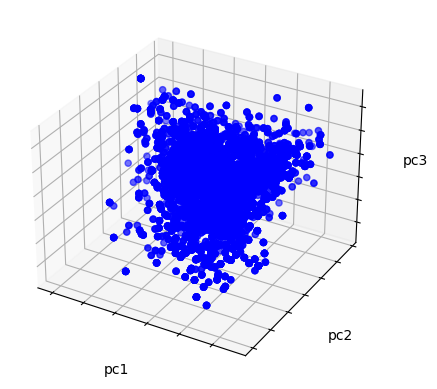

In [47]:
# choose the best cluster for each sub

from mpl_toolkits.mplot3d import Axes3D

basedir = r'/n02dat01/users/qdzhao/THINGS'
sub = '01'
fdir = pjoin(basedir, r'property_analysis/derivatives/linear_model','sub-'+sub)
# performance r
perf_r = np.load(pjoin(fdir, 'prop_pcs', f'perf_r.npz'))
pf_r = perf_r['perf_r']
# pc weights
prop_wei = np.load(pjoin(fdir, 'prop_pcs', f'prop_weight.npz')) # already surface data (vertex), not volume data (voxel)
pro_nm = ['pc1', 'pc2', 'pc3', 'pc4', 'pc5']
pc_wei = []
for p in range(3):
    pnm = pro_nm[p]+'_wei'
    pc_wei.append(prop_wei[pnm])
pc_wei = np.array(pc_wei).T #(v,3)

idx = []
pcwei_s = []
for i in range(len(pf_r)):
    if pf_r[i]>0.1:
        idx.append(i)
        pcwei_s.append(pc_wei[i])
pcwei_s = np.array(pcwei_s)


fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(pcwei_s[:,0], pcwei_s[:,1], pcwei_s[:,2], c='b', marker='o')

ax.set(xlabel='pc1',ylabel='pc2',zlabel='pc3')
ax.set(xticklabels=[],
       yticklabels=[],
       zticklabels=[])
# ax.auto_scale_xyz(pcwei_s[:,0], pcwei_s[:,1], pcwei_s[:,2])
plt.show()
# volume and surface data has the same distribution

(12719, 3)
cluster = 2


/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f7876493040>
Traceback (most recent call last):
  File "/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get

cluster = 3


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f7868f1d0d0>
Traceback (most recent call last):
  File "/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Threadpool

cluster = 4


...

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f7868f1d9d0>
Traceback (most recent call last):
  File "/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Threadpool

cluster = 7


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f7868f1dee0>
Traceback (most recent call last):
  File "/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Threadpool

cluster = 8


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f7868f1d820>
Traceback (most recent call last):
  File "/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/n02dat01/public_resource/anaconda3/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _Threadpool

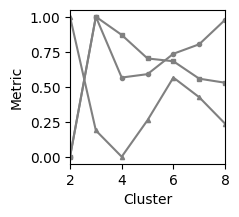

In [48]:
# k means
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,calinski_harabasz_score, davies_bouldin_score

def norm(data):
    _range = np.max(data) - np.min(data)
    return (data - np.min(data)) / _range

def std(data):
    mu = np.mean(data, axis=0)
    sigma = np.std(data, axis=0)
    return (data - mu) / sigma

n_clusters = [x for x in range(2, 9)]
x_true = pcwei_s #(v, 3)
print(x_true.shape)
s_rec = []

clu = ['Silh', 'CH', 'DB'] # ELBO
for i in range(len(n_clusters)):
    print('cluster = {}'.format(n_clusters[i]))
    # 实例化k-means分类器
    clf = KMeans(n_clusters=n_clusters[i])
    yhat = clf.fit_predict(x_true)
    
#     # 打印平均轮廓系数                                   # what about the Elbow
    s1 = silhouette_score(x_true, yhat)
    s2 = calinski_harabasz_score(x_true, yhat)
    s3 = davies_bouldin_score(x_true, yhat)
    s_rec.append([s1,s2,s3])
#     print("When cluster= {}\nThe silhouette_score= {}".format(n_clusters[i], s))
s_rec = np.array(s_rec).reshape(len(n_clusters),3)

fig = plt.figure(figsize=(2,2))
plt.rc('font',family='Arial', size=10)
plt.plot(n_clusters, norm(s_rec[:,0]), marker='o', markersize=3, color='grey')
plt.plot(n_clusters, norm(s_rec[:,1]), marker='s', markersize=3, color='grey')
plt.plot(n_clusters, norm(s_rec[:,2]), marker='^', markersize=3, color='grey')

font_dict = {'family':'Arial', 'size':10}
plt.xlim(2,8)
plt.xlabel('Cluster',fontdict=font_dict)
plt.ylabel('Metric',fontdict=font_dict)
# plt.legend(clu, loc='best',prop=font_dict)
plt.show()

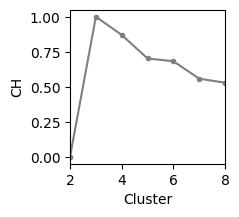

In [50]:
fig = plt.figure(figsize=(2,2))
plt.rc('font',family='Arial', size=10)
plt.plot(n_clusters, norm(s_rec[:,1]), marker='o', markersize=3, color='grey')

font_dict = {'family':'Arial', 'size':10}
plt.xlim(2,8)
plt.xlabel('Cluster',fontdict=font_dict)
plt.ylabel('CH',fontdict=font_dict)
# plt.legend(clu, loc='best',prop=font_dict)
plt.show()

In [207]:
# this code only run once, so label is stable
sub = '03'
fdir = pjoin(basedir, r'animacy_analysis\derivatives\3_pro_representation\linear model','sub-'+sub, 'prop_pcs')

x_true = pcwei_s #(v, 3)
clf = KMeans(3)
yhat = clf.fit_predict(x_true)
np.savez(pjoin(fdir,'pc_clu_label3.npz'),label = yhat) # surface data

C:\Users\qdzhao\.conda\envs\py38\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [24]:
sub = '01'
basedir = r'D:\visual_project\THINGS_project'
fdir = pjoin(basedir, r'animacy_analysis\derivatives\3_pro_representation\linear model','sub-'+sub, 'prop_pcs')
# performance r
perf_r = np.load(pjoin(fdir, f'perf_r.npz'))
pf_r = perf_r['perf_r']
# pc weights
prop_wei = np.load(pjoin(fdir, f'prop_weight.npz'))
pro_nm = ['pc1', 'pc2', 'pc3', 'pc4', 'pc5']
pc_wei = []
for p in range(3):
    pnm = pro_nm[p]+'_wei'
    pc_wei.append(prop_wei[pnm])
pc_wei = np.array(pc_wei).T #(v,3)

idx = []
pcwei_s = []
for i in range(len(pf_r)):
    if pf_r[i]>0.1:
        idx.append(i)
        pcwei_s.append(pc_wei[i])
pcwei_s = np.array(pcwei_s)                                # the threshold is r>0.1

yhat_ = np.load(pjoin(fdir, f'pc_clu_label3.npz'))
yhat = yhat_['label']

clu1 = []
clu2 = []
clu3 = []
# clu4 = []
# clu5 = []
for i in range(len(yhat)):
    if yhat[i]==0:
        clu1.append(pcwei_s[i])
    if yhat[i]==1:
        clu2.append(pcwei_s[i])
    if yhat[i]==2:
        clu3.append(pcwei_s[i])
#     if yhat[i]==3:
#         clu4.append(pcwei_s[i])
#     if yhat[i]==4:
#         clu5.append(pcwei_s[i])
clu1 = np.array(clu1)
clu2 = np.array(clu2)
clu3 = np.array(clu3)
# clu4 = np.array(clu4)
# clu5 = np.array(clu5)

In [5]:
print(np.mean(clu1,axis=0))
print(np.mean(clu2,axis=0))
print(np.mean(clu3,axis=0))

[ 0.00070381 -0.00270212 -0.00079821]
[0.00061106 0.00028177 0.00034247]
[-0.00226944 -0.00043486  0.00069837]


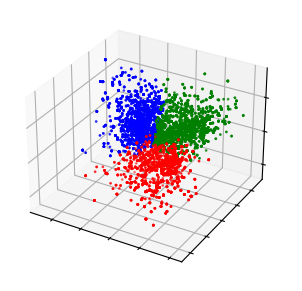

In [28]:
fig = plt.figure(figsize=(5,3.5))
ax = plt.axes(projection="3d")
# ax.scatter(clu1[:,0],clu1[:,1],clu1[:,2], c="hotpink", s=1)
# ax.scatter(clu2[:,0],clu2[:,1],clu2[:,2], c="darkgreen", s=1)
# ax.scatter(clu3[:,0],clu3[:,1],clu3[:,2], c="steelblue", s=1)
ax.scatter(clu1[:,0],clu1[:,1],clu1[:,2], c="hotpink", s=1)
ax.scatter(clu2[:,0],clu2[:,1],clu2[:,2], c="darkgreen", s=1)
ax.scatter(clu3[:,0],clu3[:,1],clu3[:,2], c="b", s=1)
# ax.scatter(clu4[:,0],clu4[:,1],clu4[:,2], c="g")
# ax.scatter3D(clu5[:,0],clu5[:,1],clu5[:,2], color="purple")
# sub-01 =[r,o,g,b], sub02=[r,b,o,g], sub03=[o,r,b,g]

# ax.set(xlabel='PC1',ylabel='PC2',zlabel='PC3')
plt.rc('font',family='Arial', size=10)
# plt.title("voxel distribution in prop pcs space")
ax.set(xticklabels=[],
       yticklabels=[],
       zticklabels=[])

# show plot
plt.show()

# code ./animacy_analysis/code/plot_3d_scatter.py

In [216]:
# cluster plot on surface
import nibabel as nib
from surfplot import Plot
from matplotlib.colors import ListedColormap


basedir = r'/n02dat01/users/qdzhao/THINGS'
sub = '01'
f_dir = pjoin(basedir, r'property_analysis/derivatives/linear_model','sub-'+sub)
outdir = pjoin(f_dir, 'plot')

subject = 'S1'
bg_dir = pjoin(basedir, r'THINGS_fMRI\pycortex_filestore', subject)
infl = pjoin(bg_dir, 'surfaces', f'inflated_lh.gii')
infr = pjoin(bg_dir, 'surfaces', f'inflated_rh.gii')

path_ref_gii = infl
metric_ref = nib.load(path_ref_gii) # 加载输入数据
loca = metric_ref.agg_data() # 获取脑区的顶点位置
numl = loca[0].shape[0] # 左脑顶点个数
# print(numl)

lb = np.zeros(pf_r.shape[0])-1 # label
for i in range(len(yhat)):
    lb[idx[i]] = yhat[i]
lb = lb+1
# print(np.unique(lb)) # 0 means nothing, 1-5 means 5 clusters

# sub-01 =[r,o,g,b], sub02=[r,b,o,g], sub03=[o,r,b,g]
# sub-01 =[r,g,b], sub02=[b,g,r], sub03=[b,r,g]
colors = ['red','green','blue'] # sub-01
# colors = ['blue','green','red'] # sub-02
# colors = ['blue','red','green'] # sub-03
cmap = ListedColormap(colors, 'regions', N=3)

p = Plot(surf_lh=infl, surf_rh=infr,zoom=1.2, views=['lateral','ventral','posterior'], brightness=0.8)
p.add_layer({'left': lb[:numl], 'right': lb[numl:]}, cmap=cmap, cbar=True)
# p.add_layer({'left': lb[:numl], 'right': lb[numl:]}, cmap='gray', as_outline=False, cbar=False)
fig = p.build()
fig.show()

plt.savefig(pjoin(outdir, f'prop_pc_cluster3.png'),dpi=300, transparent = True)
plt.close()


C:\Users\qdzhao\AppData\Local\Temp\ipykernel_21040\2681637832.py:38: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
